Creating Gaussian blobs...
Pearson correlation coefficient: 0.7984
P-value: 1.6671e-45
Unsigned Pearson correlation coefficient: -0.0224
P-value: 7.5322e-01


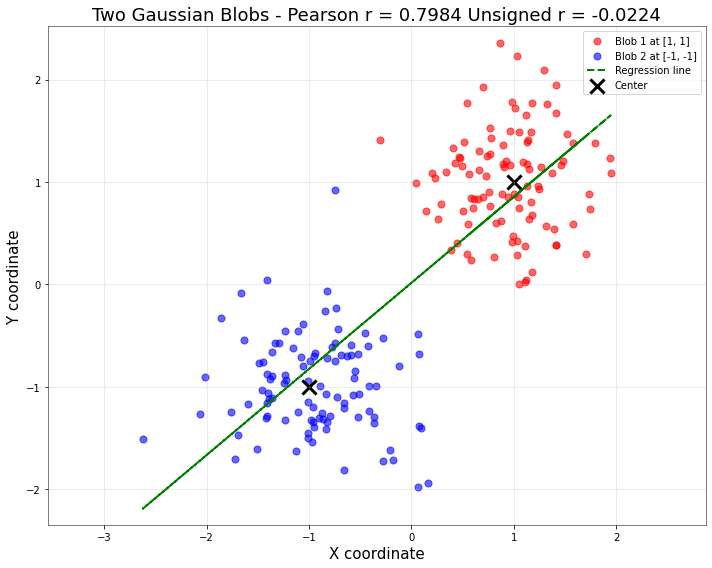

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
from sklearn.datasets import make_blobs

import matplotlib

matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42 
matplotlib.rc('axes', linewidth=0.5) 


# Set random seed for reproducibility
np.random.seed(42)

# Method 1: Using sklearn make_blobs
print("Creating Gaussian blobs...")

# Create two Gaussian blobs
centers = [[1, 1], [-1, -1]]  # Centers at (1,1) and (-1,-1)
n_samples = 200  # 100 points per blob
cluster_std = 0.5  # Standard deviation of blobs

X, y = make_blobs(n_samples=n_samples, 
                  centers=centers, 
                  cluster_std=cluster_std, 
                  random_state=42)

# Extract x and y coordinates
x_coords = X[:, 0]
y_coords = X[:, 1]

# Compute Pearson correlation
correlation, p_value = pearsonr(x_coords, y_coords)
unsigned_correlation, unsigned_p_value = pearsonr(abs(x_coords), abs(y_coords))


print(f"Pearson correlation coefficient: {correlation:.4f}")
print(f"P-value: {p_value:.4e}")
print(f"Unsigned Pearson correlation coefficient: {unsigned_correlation:.4f}")
print(f"P-value: {unsigned_p_value:.4e}")

# Fit linear regression model to data points
slope, intercept = np.polyfit(x_coords, y_coords, 1)
regression_line = slope * x_coords + intercept

# Create scatter plot
plt.figure(figsize=(10, 8))

# Color points by cluster
colors = ['red', 'blue']
for i in range(2):
    cluster_points = X[y == i]
    plt.scatter(cluster_points[:, 0], cluster_points[:, 1], 
                c=colors[i], alpha=0.6, s=50, 
                label=f'Blob {i+1} at {centers[i]}')

# Plot the regression line
plt.plot(x_coords, regression_line, color='green', linestyle='--', linewidth=2, label='Regression line')

# Add grid and labels
plt.grid(True, alpha=0.3)
plt.xlabel('X coordinate', fontsize=15)
plt.ylabel('Y coordinate', fontsize=15)
plt.title(f'Two Gaussian Blobs - Pearson r = {correlation:.4f}' + f' Unsigned r = {unsigned_correlation:.4f}', fontsize=18)
plt.legend()

# Add center markers
for i, center in enumerate(centers):
    plt.scatter(center[0], center[1], c='black', marker='x', s=200, 
                linewidths=3, label='Center' if i == 0 else '')

plt.legend()
plt.axis('equal')  # Equal aspect ratio
plt.tight_layout()

plt.savefig("figures/gaussian_blobs.pdf", transparent=True, dpi=300)

#plt.show()